In [2]:
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.autograd import Variable
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [3]:
mean_gray = 0.1307
stddev_gray = 0.3081

In [4]:
# input[channel] = (input[channel] - mean[channel]) / std[channel]
transforms_ori = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((mean_gray,), (stddev_gray,))])

#Load dataset
train_dataset = datasets.MNIST(root = './data', 
                            train = True, 
                            transform = transforms_ori,
                            download = True)

test_dataset = datasets.MNIST(root = './data', 
                            train = False, 
                            transform = transforms_ori)


tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0

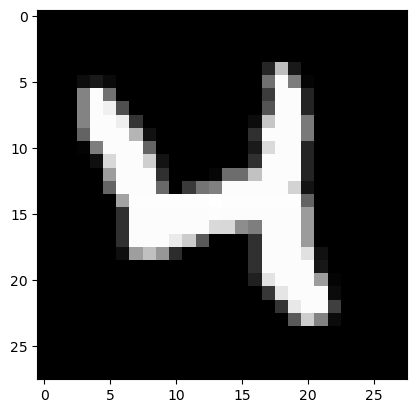

In [5]:
random_img = train_dataset[20][0].numpy() * stddev_gray + mean_gray
print(train_dataset[20][0])
print(train_dataset[20][0].numpy().shape)
plt.imshow(random_img.reshape(28,28,1), cmap = 'gray') # (C,H,W) -> (H,W,C)
print(train_dataset[20][1])

In [6]:
batch_size = 100
train_load = torch.utils.data.DataLoader(dataset = train_dataset,
                                         batch_size = batch_size,
                                         shuffle = True)

test_load = torch.utils.data.DataLoader(dataset = test_dataset,
                                         batch_size = batch_size,
                                         shuffle = False)

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Same padding = (filter_size - 1)/2
        self.cnn1 = nn.Conv2d(in_channels = 1, out_channels = 8, kernel_size = 3, stride = 1, padding = 1)
        # The output size of each of the 8 feature maps
        # [(input_size - filter_size + 2(padding) / stride) +1] --> [(28-3+2(1)/1)+1] = 28 (padding type is same)
        self.batchnorm1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size = 2)
        # The output size = 28/2 = 14
        self.cnn2 = nn.Conv2d(in_channels = 8, out_channels = 32, kernel_size = 5, stride = 1, padding = 2)
        # Output size of each of the 32 feature maps: 14
        self.batchnorm2 = nn.BatchNorm2d(32)
        self.fc1 = nn.Linear(1568,600)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(600,10)

    def forward(self, x):
        out = self.cnn1(x)
        out = self.batchnorm1(out)
        out = self.relu(out)
        out = self.maxpool(out)
        out = self.cnn2(out)
        out = self.batchnorm2(out)
        out = self.relu(out)
        out = self.maxpool(out)
        # Flatten the 32 feature maps
        out = out.view(-1, 1568)

        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out
    

In [8]:
model = CNN()

In [9]:

CUDA = torch.cuda.is_available()
print(CUDA)
if CUDA:
    model = model.cuda()

loss_fn = nn.CrossEntropyLoss() # Already Softmax
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

False


In [46]:
num_epochs = 10
train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []

for epoch in range(num_epochs):
    correct = 0
    iterations = 0
    iter_loss = 0.0

    model.train() # Alert the training session to the program (here for the Dropout
                  # when to turn on and off)

    for i, (inputs, labels) in enumerate(train_load):

        if CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        iter_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Record the correct predictions for training data 
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        iterations += 1

    train_loss.append(iter_loss/iterations)
    train_accuracy.append(correct / len(train_dataset))

    # Testing phase
    loss = 0.0
    correct = 0
    iterations = 0

    model.eval()

    for i, (inputs, labels) in enumerate(test_load):

        if CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = model(inputs)
        loss_now = loss_fn(outputs, labels)
        loss += loss_now.item()

        # Record the correct predictions for testing data 
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        iterations += 1

    test_loss.append(loss/iterations)
    test_accuracy.append(correct / len(test_dataset))

    print ('Epoch {}/{}, Training Loss: {:.3f}, Training Accuracy: {:.3f}, Testing Loss: {:.3f}, Testing Acc: {:.3f}'
           .format(epoch+1, num_epochs, train_loss[-1], train_accuracy[-1], 
             test_loss[-1], test_accuracy[-1]))

Epoch 1/10, Training Loss: 0.470, Training Accuracy: 0.878, Testing Loss: 0.139, Testing Acc: 0.963
Epoch 2/10, Training Loss: 0.145, Training Accuracy: 0.959, Testing Loss: 0.089, Testing Acc: 0.975
Epoch 3/10, Training Loss: 0.106, Training Accuracy: 0.969, Testing Loss: 0.070, Testing Acc: 0.979
Epoch 4/10, Training Loss: 0.086, Training Accuracy: 0.974, Testing Loss: 0.059, Testing Acc: 0.983
Epoch 5/10, Training Loss: 0.074, Training Accuracy: 0.978, Testing Loss: 0.052, Testing Acc: 0.983
Epoch 6/10, Training Loss: 0.067, Training Accuracy: 0.981, Testing Loss: 0.048, Testing Acc: 0.985
Epoch 7/10, Training Loss: 0.060, Training Accuracy: 0.982, Testing Loss: 0.045, Testing Acc: 0.986
Epoch 8/10, Training Loss: 0.055, Training Accuracy: 0.984, Testing Loss: 0.041, Testing Acc: 0.986
Epoch 9/10, Training Loss: 0.051, Training Accuracy: 0.985, Testing Loss: 0.040, Testing Acc: 0.986
Epoch 10/10, Training Loss: 0.048, Training Accuracy: 0.986, Testing Loss: 0.039, Testing Acc: 0.987

In [10]:
torch.save(model.state_dict(),'CNN_MNIST.pth')

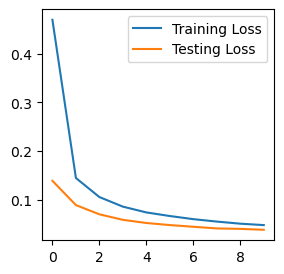

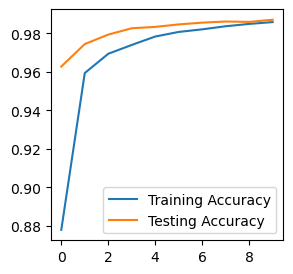

In [48]:
# Print loss
f = plt.figure(figsize=(3, 3))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Testing Loss')
plt.legend()
plt.show()

# Print accuracy
f = plt.figure(figsize=(3, 3))
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(test_accuracy, label='Testing Accuracy')
plt.legend()
plt.show()

In [49]:
img = test_dataset[30][0].resize_((1,1,28,28)) # Both resize_ and view are okay
label = test_dataset[30][1]

model.eval()
if CUDA:
    model = model.cuda()
    img = img.cuda()

output = model(img)
_, predicted = torch.max(output,1)
print("Prediction is: {}".format(predicted.item()))
print("Actual label is: {}".format(label))


Prediction is: 3
Actual label is: 3


In [11]:
model.load_state_dict(torch.load('CNN_MNIST.pth'))

<All keys matched successfully>

In [ ]:
transforms_photo = transforms.Compose([transforms.Resize((28,28)),
                                       transforms.ToTensor(),
                                       transforms.Normalize((mean_gray,), (stddev_gray,))])

def predict(img_name,model):
    image = cv2.imread(img_name,0)   #Read the image
    ret, thresholded = cv2.threshold(image,127,255,cv2.THRESH_BINARY)   #Threshold the image
    img = 255-thresholded           #Apply image negative
    img = Image.fromarray(img)      #Convert the image to an array
    img = transforms_photo(img)     #Apply the transformations 
    img = img.view(1,1,28,28)       #Add batch size 
    img = Variable(img)             #Wrap the tensor to a variable
    
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()
        img = img.cuda()

    output = model(img)
    print(output)
    print(output.data)
    _, predicted = torch.max(output,1)
    return  predicted.item()


In [ ]:
pred = predict('number5.jpg', model)
print("The Predicted Label is {}".format(pred))

tensor([[ 0.0129, -0.0182, -0.0085,  0.0602,  0.0152,  0.0016, -0.0068, -0.0163,
         -0.0078, -0.0073]], grad_fn=<AddmmBackward0>)
tensor([[ 0.0129, -0.0182, -0.0085,  0.0602,  0.0152,  0.0016, -0.0068, -0.0163,
         -0.0078, -0.0073]])
The Predicted Label is 3


: 